# S7B: Static multi-station bearing triangulation

Bearing-level validation in a right-handed ENU frame. This notebook does not run GCC/SRP, does not pass true range to the estimator, and does not implement dynamic tracking or retarded-time fusion. Position covariance is a local Gaussian linearization benchmark, not an exact signal-level CRLB.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from estimators.bearing_triangulation import triangulate_bearings_spherical_wls
from model.measurements import BearingMeasurement
from validation.multistation_static_study import (
    DEFAULT_CALIBRATION_REALIZATIONS,
    DEFAULT_EVALUATION_REALIZATIONS,
    build_static_scene,
    default_static_study_configurations,
    run_multistation_static_study,
)
from visualization.multistation_scene import plot_multistation_scene

## Fixed-seed study

Each physical geometry uses independent calibration/evaluation bearing-noise streams. The same tangent-plane draws are reused across matched station-count/mismatch scenarios (common random numbers). Residual components are not counted as independent realizations.

In [2]:
records, geometry_records = run_multistation_static_study(
    summary_csv=ROOT / 'results' / 'multistation_static_summary.csv',
    geometry_csv=ROOT / 'results' / 'multistation_geometry_summary.csv',
)
assert len(records) == 9 * 7 * 2
assert len(geometry_records) == 9
assert all(not row['truth_used_online'] for row in records)
assert all(not row['dynamic_tracking_implemented'] for row in records)
assert all(not row['retarded_time_fusion_implemented'] for row in records)
assert all(row['calibration_evaluation_seed_overlap_count'] == 0 for row in records)
print(f'calibration/evaluation realizations per physical configuration: {DEFAULT_CALIBRATION_REALIZATIONS}/{DEFAULT_EVALUATION_REALIZATIONS}')
print(f'summary/geometry rows: {len(records)}/{len(geometry_records)}')

calibration/evaluation realizations per physical configuration: 128/256
summary/geometry rows: 126/9


In [3]:
evaluation = [row for row in records if row['split'] == 'evaluation']
ideal_three = [row for row in evaluation if row['scenario'] == 'ideal_three']
print('configuration                     RMSE[m]   P95[m]   P99[m]   cond(median)')
for row in ideal_three:
    print(f"{row['physical_configuration']:31s} {row['position_rmse_m']:8.3f} {row['position_error_p95_m']:8.3f} {row['position_error_p99_m']:8.3f} {row['information_condition_median']:12.3g}")

configuration                     RMSE[m]   P95[m]   P99[m]   cond(median)
equilateral_near                   0.296    0.504    0.639         5.37
equilateral_mid                    1.822    3.446    4.256         45.4
equilateral_far                   20.213   36.603   56.754          615
equilateral_scale_small            0.854    1.551    1.900         45.9
equilateral_scale_large            4.342    8.286   10.580         45.1
elongated_mid                      3.131    6.392    8.979          168
near_collinear_far                38.550   64.868  134.490     1.69e+03
equilateral_oriented               1.616    2.913    3.837         49.1
elongated_oriented                23.561   44.050   58.955          613


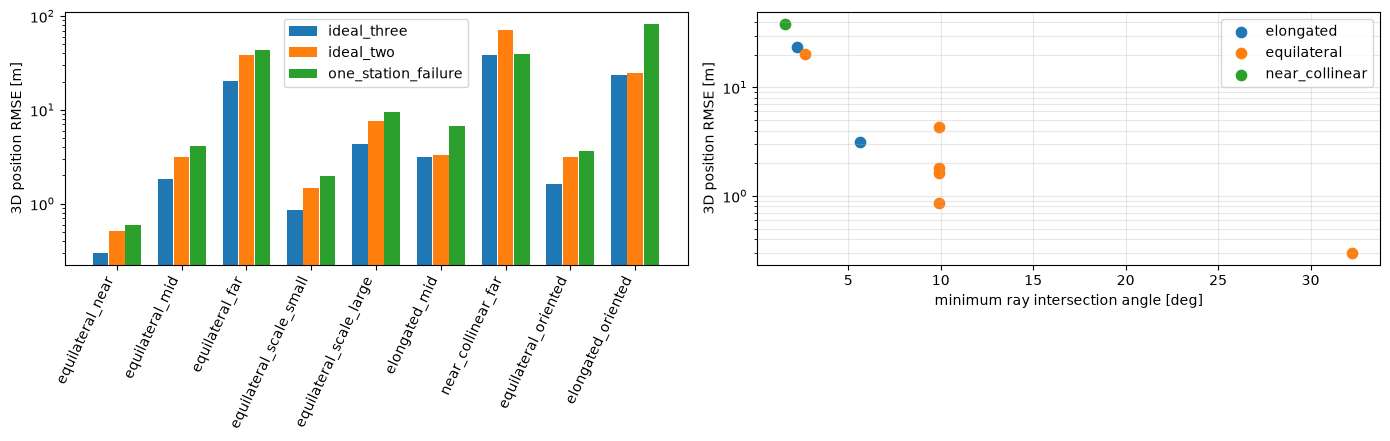

In [4]:
names = [row['physical_configuration'] for row in ideal_three]
x = np.arange(len(names))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for offset, scenario in zip((-0.25, 0.0, 0.25), ('ideal_three', 'ideal_two', 'one_station_failure')):
    rows = [next(row for row in evaluation if row['physical_configuration'] == name and row['scenario'] == scenario) for name in names]
    axes[0].bar(x + offset, [row['position_rmse_m'] for row in rows], width=0.24, label=scenario)
axes[0].set_yscale('log')
axes[0].set_ylabel('3D position RMSE [m]')
axes[0].set_xticks(x, names, rotation=65, ha='right')
axes[0].legend()
for geometry in sorted({row['station_geometry'] for row in ideal_three}):
    rows = [row for row in ideal_three if row['station_geometry'] == geometry]
    axes[1].scatter([row['minimum_ray_intersection_angle_deg'] for row in rows], [row['position_rmse_m'] for row in rows], label=geometry, s=55)
axes[1].set_yscale('log')
axes[1].set_xlabel('minimum ray intersection angle [deg]')
axes[1].set_ylabel('3D position RMSE [m]')
axes[1].grid(True, which='both', alpha=0.3)
axes[1].legend()
fig.tight_layout()

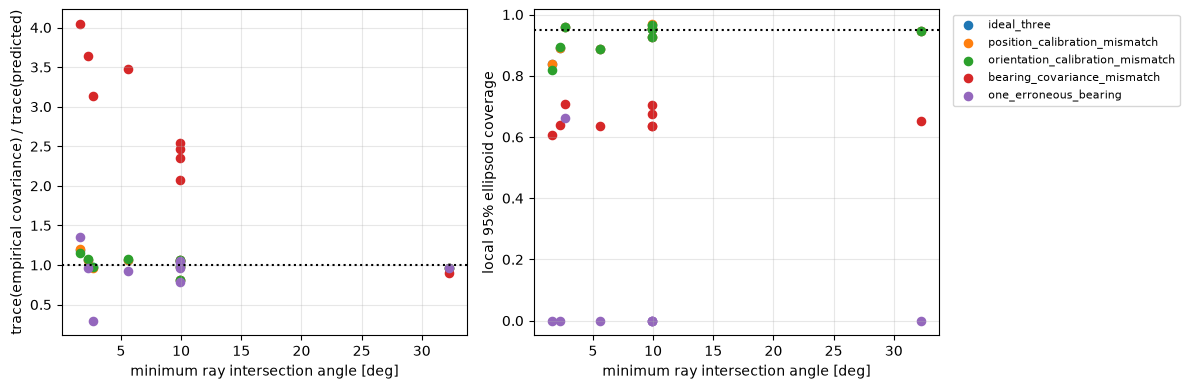

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for scenario in ('ideal_three', 'position_calibration_mismatch', 'orientation_calibration_mismatch', 'bearing_covariance_mismatch', 'one_erroneous_bearing'):
    rows = [row for row in evaluation if row['scenario'] == scenario]
    axes[0].scatter([row['minimum_ray_intersection_angle_deg'] for row in rows], [row['predicted_empirical_covariance_trace_ratio'] for row in rows], label=scenario, s=35)
    axes[1].scatter([row['minimum_ray_intersection_angle_deg'] for row in rows], [row['position_ellipsoid_p95_coverage'] for row in rows], label=scenario, s=35)
axes[0].axhline(1.0, color='black', linestyle=':')
axes[0].set_ylabel('trace(empirical covariance) / trace(predicted)')
axes[1].axhline(0.95, color='black', linestyle=':')
axes[1].set_ylabel('local 95% ellipsoid coverage')
for axis in axes:
    axis.set_xlabel('minimum ray intersection angle [deg]')
    axis.grid(True, alpha=0.3)
axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()

## ENU validation scenes

The true position marker is explicitly validation-only. The estimator receives station poses and bearing measurements, not true position or range. Gray segments show the closest-point residual from each measured ray to the estimated 3D point; the wireframe is the local 95% Gaussian covariance ellipsoid.

In [6]:
def ideal_validation_result(configuration_index):
    config = default_static_study_configurations()[configuration_index]
    stations, target = build_static_scene(config)
    measurements = []
    for station in stations:
        world = target - station.position_world_m
        world /= np.linalg.norm(world)
        local = station.world_to_local_direction(world)
        measurements.append(BearingMeasurement(
            station.station_id, 'notebook-validation', 0, 0.0, 0.01, local,
            np.diag(np.deg2rad([0.35, 0.55])**2), np.zeros(2), 'ideal-bearing'))
    result = triangulate_bearings_spherical_wls(stations, measurements)
    return config, stations, measurements, target, result

Text(0.5, 0.92, 'Good geometry: equilateral_near')

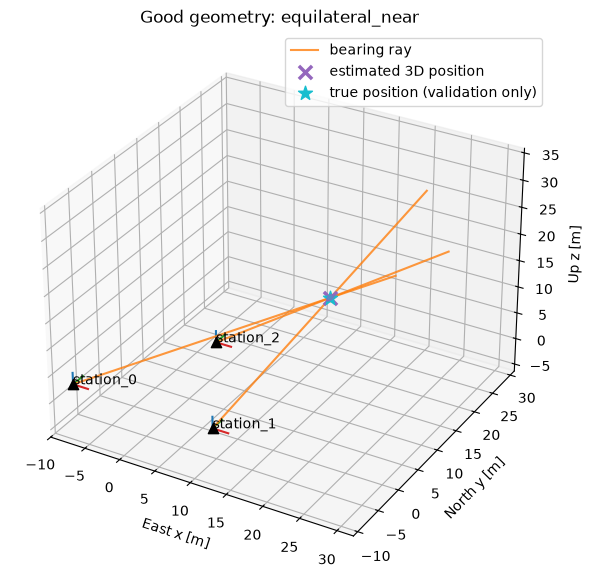

In [7]:
config, stations, measurements, target, result = ideal_validation_result(0)
assert result.valid
figure, axis = plot_multistation_scene(stations, measurements, result, true_position_world_m=target, validation_mode=True)
axis.set_title(f'Good geometry: {config.name}')

Text(0.5, 0.92, 'Poor geometry: near_collinear_far; information condition=1.83e+03')

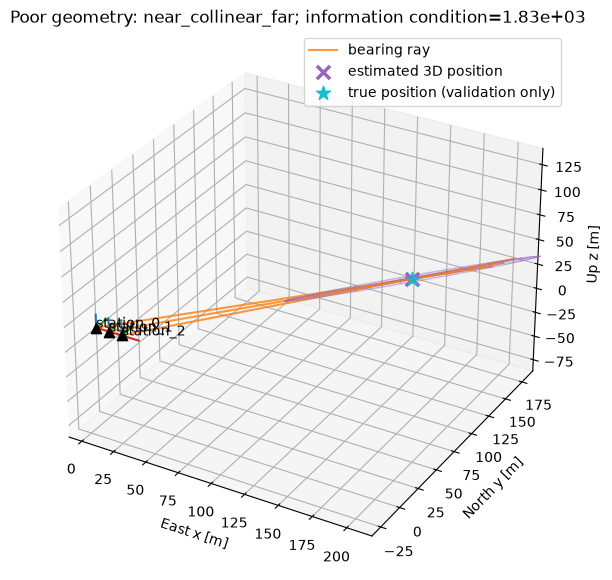

In [8]:
config_bad, stations_bad, measurements_bad, target_bad, result_bad = ideal_validation_result(6)
figure, axis = plot_multistation_scene(stations_bad, measurements_bad, result_bad, true_position_world_m=target_bad, validation_mode=True)
axis.set_title(f'Poor geometry: {config_bad.name}; information condition={result_bad.information_condition_number:.3g}')

In [9]:
assert all(row['information_rank_min'] == 3 for row in evaluation if row['coverage'] > 0)
assert all(row['position_bias_centering_source_split'] == 'calibration' for row in evaluation)
assert all(not row['evaluation_mean_used_for_position_error_centering'] for row in evaluation)
worst = max(ideal_three, key=lambda row: row['information_condition_median'])
print('Worst-conditioned ideal-three configuration:', worst['physical_configuration'])
print('condition:', worst['information_condition_median'], 'RMSE [m]:', worst['position_rmse_m'])
print('Static simultaneous-state triangulation only; dynamic 3D tracking is not implemented.')

Worst-conditioned ideal-three configuration: near_collinear_far
condition: 1692.8981979089167 RMSE [m]: 38.54975669724642
Static simultaneous-state triangulation only; dynamic 3D tracking is not implemented.
